In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.table import vstack
from astropy.cosmology import FlatLambdaCDM
from scipy.stats import ttest_rel
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator
import os

FIG_DIR = "/raid/scratch/work/alberttg/Masters_project/Plots"

In [135]:
def fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            # hdul.info()
            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))

        # Print column names
        # print("\nColumns:")
        # print(tbl.colnames)

        return tbl

In [136]:
def add_marginal_hists(ax, x, y, bins=30, size="15%", pad=0.1, color="gray"):
    """
    Add marginal histograms of x and y on top of and to the right of ax,
    without disturbing ax's existing content (scatter, legend, etc.).

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to attach histograms to.
    x, y : array-like
        Data for the x and y histograms.
    bins : int
        Number of histogram bins.
    size : str
        Size of the marginal axes relative to ax (e.g. "15%").
    pad : float
        Padding between ax and the marginal axes.
    color : str
        Histogram color.

    Returns
    -------
    ax_histx, ax_histy : the two new marginal axes
    """
    divider = make_axes_locatable(ax)

    # Top histogram (x-axis distribution)
    ax_histx = divider.append_axes("top", size=size, pad=pad, sharex=ax)
    ax_histx.hist(x, bins=bins, color=color, edgecolor='0.2', linewidth=0.5)
    ax_histx.tick_params(axis="x", labelbottom=False)  # hide x labels (shared with ax)
    ax_histx.set_yticks([])
    for spine in ["top", "right", "left"]:
        ax_histx.spines[spine].set_visible(False)

    # Right histogram (y-axis distribution)
    ax_histy = divider.append_axes("right", size=size, pad=pad, sharey=ax)
    ax_histy.hist(y, bins=bins, orientation="horizontal", color=color, edgecolor='0.2', linewidth=0.5)
    ax_histy.tick_params(axis="y", labelleft=False)  # hide y labels (shared with ax)
    ax_histy.set_xticks([])
    for spine in ["top", "right", "bottom"]:
        ax_histy.spines[spine].set_visible(False)

    return ax_histx, ax_histy

In [137]:
def plot_binned_medians_for_distribution(
    ax, x, y,
    x_upper_err, x_lower_err, y_upper_err, y_lower_err,
    n_bins, bin_axis, bin_axis_name,
    marker="s", markersize=14, markeredgecolor="black",
    markeredgewidth=1.5, color="red", **errorbar_kwargs
):
    """
    Bin data along `bin_axis`, compute the median of x and y within each bin,
    and plot the medians on `ax` with error bars derived from per-point
    error arrays. Marker style: thick-edged star. Not defined bin widths,
    instead displays the distribution of points. Is a bit dodgy.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on (existing content is preserved).
    x, y : array-like
        Data points.
    x_upper_err, x_lower_err, y_upper_err, y_lower_err : array-like
        Per-point asymmetric errors, same length as x/y.
    n_bins : int or array-like
        Desired number of bins, or explicit bin edges. If an int, it will
        be reduced automatically (see `min_points_per_bin`) and bin edges
        are chosen so each bin contains roughly equal numbers of points.
        If array-like, used as explicit bin edges (no automatic adjustment).
    bin_axis : {"x", "y"}
        Which variable to bin on.
    bin_axis_name:
        For the label on the median of binned points.
    marker, markersize, markeredgecolor, markeredgewidth, color :
        Passed to ax.errorbar for marker styling.
    **errorbar_kwargs :
        Any additional kwargs forwarded to ax.errorbar.

    Returns
    -------
    bin_x, bin_y, xerr, yerr : ndarrays
        The computed bin medians and their [lower, upper] error arrays
        (xerr and yerr have shape (2, n_bins)).
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x_upper_err = np.zeros_like(x) if x_upper_err is None else np.asarray(x_upper_err)
    x_lower_err = np.zeros_like(x) if x_lower_err is None else np.asarray(x_lower_err)

    y_upper_err = np.zeros_like(y) if y_upper_err is None else np.asarray(y_upper_err)
    y_lower_err = np.zeros_like(y) if y_lower_err is None else np.asarray(y_lower_err)

    bin_data = x if bin_axis == "x" else y

    if np.isscalar(n_bins):
        n_data = len(bin_data)
        # Equal-count (quantile) bin edges, so each bin gets ~n_data/n_bins points
        sorted_data = np.sort(bin_data)
        quantile_positions = np.linspace(0, n_data - 1, n_bins + 1)
        edges = np.interp(quantile_positions, np.arange(n_data), sorted_data)
        # Guard against duplicate edges (e.g. many repeated values)
        edges = np.unique(edges)
        n_bins = len(edges) - 1
    else:
        edges = np.asarray(n_bins)
        n_bins = len(edges) - 1

    bin_idx = np.digitize(bin_data, edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)  # ensure max value falls in last bin


    def bootstrap_median_errors(values, n_boot=5000, random_state=None):
        """
        Bootstrap estimate of asymmetric uncertainty on the median.

        Returns
        -------
        median, upper_err, lower_err
        """
        values = np.asarray(values)
        rng = np.random.default_rng(random_state)

        n = len(values)

        boot = np.empty(n_boot)

        for i in range(n_boot):
            sample = rng.choice(values, size=n, replace=True)
            boot[i] = np.median(sample)

        median = np.median(values)

        lo, hi = np.percentile(boot, [16, 84])

        return median, hi - median, median - lo


    bin_x, bin_y = [], []
    xerr_lo, xerr_hi = [], []
    yerr_lo, yerr_hi = [], []

    for i in range(n_bins):
        mask = bin_idx == i
        n = mask.sum()

        x_med, x_hi, x_lo = bootstrap_median_errors(x[mask])
        y_med, y_hi, y_lo = bootstrap_median_errors(y[mask])

        bin_x.append(x_med)
        xerr_lo.append(x_lo)
        xerr_hi.append(x_hi)

        bin_y.append(y_med)
        yerr_lo.append(y_lo)
        yerr_hi.append(y_hi)
    

    bin_x = np.array(bin_x)
    bin_y = np.array(bin_y)
    xerr = np.array([xerr_lo, xerr_hi])
    yerr = np.array([yerr_lo, yerr_hi])

    ax.errorbar(
        bin_x, bin_y, xerr=xerr, yerr=yerr,
        fmt=marker, markersize=markersize,
        markeredgecolor=markeredgecolor, markeredgewidth=markeredgewidth,
        color=color, linestyle="none", **errorbar_kwargs,
        label=f"Median of binned {bin_axis_name}", zorder=3
    )

    return bin_x, bin_y, xerr, yerr


In [138]:
def redshift_bins(redshifts, y_values, ax, marker_style, marker_size, colour):
    """
    Bin the data by redshift and compute the median and bootstrap errors for each bin.

    Parameters
    ----------
    redshifts : array-like
        The redshift values.
    y_values : array-like
        The corresponding y-values to compute statistics on.
    ax : matplotlib.axes.Axes
        The axes on which to plot the binned data.
    marker_style : str
        Square or diamond or circle points for the plot.
    marker_size : float
        Size of the points for the plot.
    colour : str
        Color of the points for the plot.
    """
    bins = [[6.5, 7.5], [7.5, 8.5], [8.5, 9.5], [9.5, 10.5], [10.5, 11.5], [11.5, 12.5], [12.5, 13.5], [13.5, 14.5], [14.5, 15.5]]
    # We've set z=6.5 as the minimum and the highest redshift galaxies are at 15 and one at 15.9.

    bin_centers = []
    medians = []
    upper_errors = []
    lower_errors = []

    for i in range(len(bins)):
        bin_mask = (redshifts >= bins[i][0]) & (redshifts < bins[i][1])
        bin_redshifts = redshifts[bin_mask]
        bin_y_values = y_values[bin_mask]

        if len(bin_y_values) > 5:
            # Stops error message when there are no galaxies in a bin
            median = np.median(bin_y_values)
            upper_err = np.percentile(bin_y_values, 84) - median
            lower_err = median - np.percentile(bin_y_values, 16)
            bin_center = np.mean(bins[i])

            bin_centers.append(bin_center)
            medians.append(median)
            upper_errors.append(upper_err)
            lower_errors.append(lower_err)

    ax.errorbar(bin_centers, medians, yerr=[lower_errors, upper_errors], 
                fmt=marker_style, markersize=marker_size,
                markeredgecolor='black', markeredgewidth=1,
                color=colour, linestyle="none",
                label=f"Median of binned redshifts", zorder=3
            )
    
    return bin_centers, medians, upper_errors, lower_errors


In [139]:
def plot_median_bins(x_values, y_values, n_bins, binned_axis_name, ax, marker_style, marker_size, colour):
    """
    Bin the data by redshift and compute the median and 16th and 84th percentiles for each bin.
    Ensures there must be at least 5 galaxies in a bin.
    Plots the median values with error bars on the provided axes.

    Parameters
    ----------
    x_values : array-like
        The x-values to bin.
    y_values : array-like
        The corresponding y-values to compute statistics on.
    n_bins : int
        The number of bins to use for binning the data.
    ax : matplotlib.axes.Axes
        The axes on which to plot the binned data.
    marker_style : str
        Square or diamond or circle points for the plot.
    marker_size : float
        Size of the points for the plot.
    colour : str
        Color of the points for the plot.
    """
    bins = np.linspace(x_values.min(), x_values.max(), n_bins + 1)

    bins = [[bins[i], bins[i + 1]] for i in range(len(bins) - 1)]

    bin_centers = []
    medians = []
    upper_errors = []
    lower_errors = []

    for i in range(len(bins)):
        bin_mask = (x_values >= bins[i][0]) & (x_values < bins[i][1])
        bin_x_values = x_values[bin_mask]
        bin_y_values = y_values[bin_mask]

        if len(bin_y_values) > 5:
            # Stops error message when there are no galaxies in a bin
            median = np.median(bin_y_values)
            upper_err = np.percentile(bin_y_values, 84) - median
            lower_err = median - np.percentile(bin_y_values, 16)
            bin_center = np.mean(bins[i])

            bin_centers.append(bin_center)
            medians.append(median)
            upper_errors.append(upper_err)
            lower_errors.append(lower_err)

    ax.errorbar(bin_centers, medians, yerr=[lower_errors, upper_errors], 
                fmt=marker_style, markersize=marker_size,
                markeredgecolor='black', markeredgewidth=1,
                color=colour, linestyle="none",
                label=f"Median of binned {binned_axis_name}", zorder=3
            )
    
    return bin_centers, medians, upper_errors, lower_errors


In [140]:
def open_catalogue_data(path):
  """
  Reads in a catalogue of data from a FITS file and returns the data as an Astropy Table.
  """

  hdul = fits.open(path)
  hdu_names = [hdu.name for hdu in hdul]

  # sex_cat = [hdu for hdu, name in zip(hdul, hdu_names) if name == "OBJECTS"][0]
    
  # EPOCHS series (Conselice+24, Adams+24, Austin+25, Harvey+25)

  sex_tab = Table.read(path, hdu = "OBJECTS")
  sex_tab_colnames = sex_tab.colnames
  # print(sex_tab_colnames)
  # sky position (Ra = ALPHA_J2000, Dec = DELTA_J2000)
  # flux columns: FLUX_APER_{band}_aper_corr_Jy [Jy]
  # flux error columns: FLUXERR_APER_{band}_loc_depth_5pc_Jy [Jy]

  bagpipes_zfix = Table.read(path, hdu = "BAGPIPES_SFH_CONT_BURSTY_ZEAZYSFHZBLUEAGN_3.0,10.0MYR_CALZETTI_LOG_10_Z_LOG_10_BPASS_ZFIX")
  # ext 3

  bagpipes_zgauss = Table.read(path, hdu = "BAGPIPES_SFH_CONT_BURSTY_ZEAZYSFHZBLUEAGN_3.0,10.0MYR_CALZETTI_LOG_10_Z_LOG_10_BPASS_ZGAUSS_3.0SIG")
  # ext 4

  return sex_tab, bagpipes_zfix, bagpipes_zgauss

In [141]:
def masked_table(sex_tab, bagpipes_zfix, bagpipes_zgauss):
    """
    Filtered zgauss table for galaxies with z >=6.5.
    Found the corresponding galaxy ids in zfix.
    Added the zgauss redshift values to the zfix table.
    """

    redshift = bagpipes_zgauss["redshift_50"]

    z_mask = redshift >= 6.5

    survey_id = bagpipes_zgauss["#ID"]
    sampled_survey_id = survey_id[z_mask]
    # The ids of galaxies in zgauss table with redshift >= 6.5, which are the same in zfix
    # print("Redshift filtered ids: ", sampled_survey_id)

    zfix_sample = bagpipes_zfix[np.isin(bagpipes_zfix["#ID"], sampled_survey_id)]
    # Now filtered for redshift >= 6.5

    # print("Number of galaxies in our sample: ", len(zfix_sample))

    # print("Number of redshift mask: ", len(bagpipes_zgauss["redshift_50"][z_mask]))

    zfix_sample["redshift_50"] = np.zeros(len(zfix_sample), dtype=float)

    for i in range(len(zfix_sample)):
        if zfix_sample["#ID"][i] in sampled_survey_id:
            z = bagpipes_zgauss["redshift_50"][np.where(zfix_sample["#ID"][i] == bagpipes_zgauss["#ID"].data)[0][0]]
            zfix_sample["redshift_50"][i] = z

    # print("Check length: ", len(zfix_sample["redshift_50"]))

    return zfix_sample


In [142]:
def plot_stellar_mass_vs_redshift(sample_table):

    log_stellar_mass_Q16 = sample_table["stellar_mass_16"]
    log_stellar_mass_Q50 = sample_table["stellar_mass_50"]
    log_stellar_mass_Q84 = sample_table["stellar_mass_84"]

    log_stellar_mass_upper_err = log_stellar_mass_Q84 - log_stellar_mass_Q50
    log_stellar_mass_lower_err = log_stellar_mass_Q50 - log_stellar_mass_Q16

    redshift = sample_table["redshift_50"]


    fig, ax = plt.subplots(figsize=(10, 10))

    # plt.errorbar(redshift, log_stellar_mass_Q50, yerr=[log_stellar_mass_lower_err, log_stellar_mass_upper_err], fmt='o', ecolor='black', alpha=0.5)
    # plt.scatter(redshift, log_stellar_mass_Q50, color='steelblue', alpha=0.6)

    plt.xlabel(r'Redshift $z_{spec}$', fontsize=18)
    plt.ylabel(r'Log Stellar Mass $log_{10}(M_*/M_\odot)$', fontsize=18)
    plt.grid(True)

    plt.hexbin(redshift, log_stellar_mass_Q50, cmap='Blues', alpha=1.0)

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    add_marginal_hists(ax, x=redshift, y=log_stellar_mass_Q50, bins=30, size="15%", pad=0.1, color="steelblue")

    redshift_bins(redshift, log_stellar_mass_Q50, ax, "s", 8, "orange")

    ax.legend(loc="upper right", fontsize=15)

    fig_path = os.path.join(FIG_DIR, "stellar_mass_vs_redshift.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    plt.show()

In [143]:
def plot_stellar_mass_vs_M_UV(sample_table):

    log_stellar_mass_Q16 = sample_table["stellar_mass_16"]
    log_stellar_mass_Q50 = sample_table["stellar_mass_50"]
    log_stellar_mass_Q84 = sample_table["stellar_mass_84"]

    log_stellar_mass_upper_err = log_stellar_mass_Q84 - log_stellar_mass_Q50
    log_stellar_mass_lower_err = log_stellar_mass_Q50 - log_stellar_mass_Q16

    M_uv_Q16 = sample_table["M_UV_16"]
    M_uv_Q50 = sample_table["M_UV_50"]
    M_uv_Q84 = sample_table["M_UV_84"]


    fig, ax = plt.subplots(figsize=(10, 10))

    # plt.errorbar(redshift, log_stellar_mass_Q50, yerr=[log_stellar_mass_lower_err, log_stellar_mass_upper_err], fmt='o', ecolor='black', alpha=0.5)
    # plt.scatter(M_uv_Q50, log_stellar_mass_Q50, color='steelblue', alpha=0.6)

    plt.xlabel(r'M$_{UV}$', fontsize=18)
    plt.ylabel(r'Log Stellar Mass $log_{10}(M_*/M_\odot)$', fontsize=18)
    plt.grid(True)

    plt.hexbin(M_uv_Q50, log_stellar_mass_Q50, cmap='Blues', alpha=1.0)

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    add_marginal_hists(ax, x=M_uv_Q50, y=log_stellar_mass_Q50, bins=30, size="15%", pad=0.1, color="steelblue")

    plot_median_bins(
        x_values=M_uv_Q50, y_values=log_stellar_mass_Q50, n_bins=8, binned_axis_name="M$_{UV}$",
        ax=ax, marker_style="s", marker_size=8, colour="orange"
    )

    ax.legend(loc="lower left", fontsize=15)

    fig_path = os.path.join(FIG_DIR, "stellar_mass_vs_M_UV.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    plt.show()

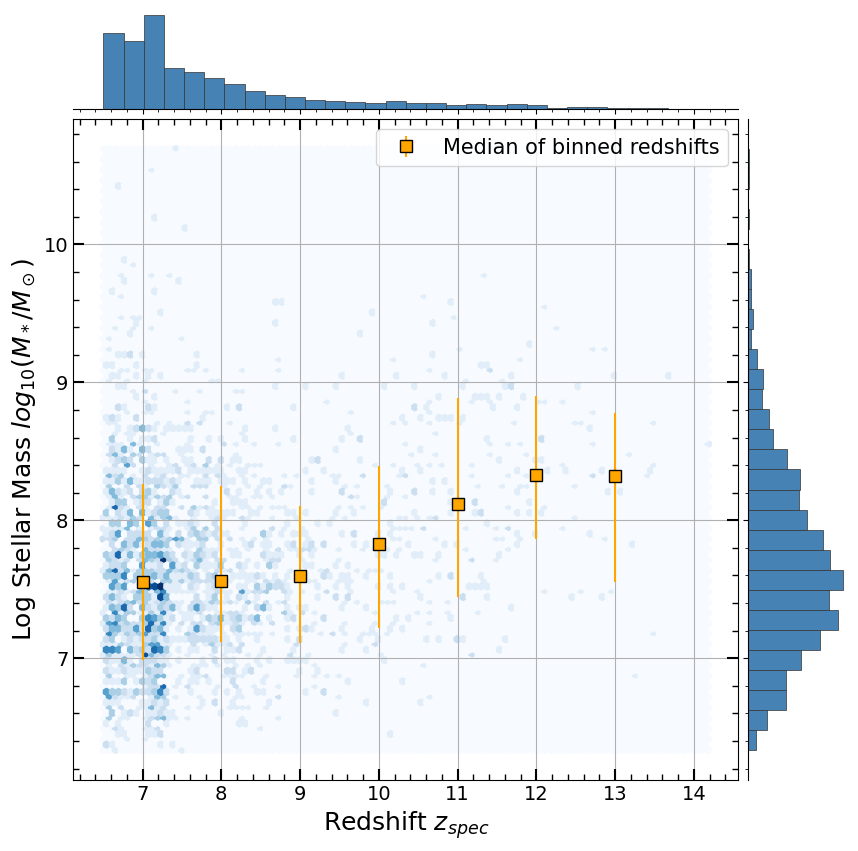

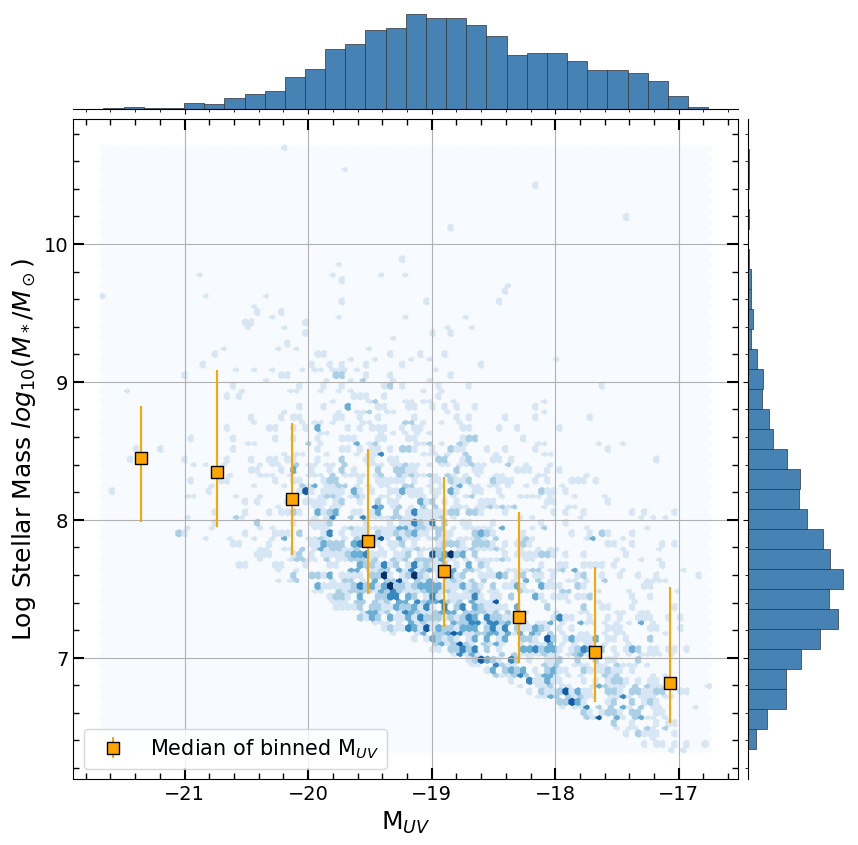

In [144]:
if __name__ == "__main__":

    epochs_table_path = "/raid/scratch/work/alberttg/Masters_project/Data_inputs/EPOCHS-v2_EPOCHS_good_EAZY_sfhz_blue_agn_zfree_MASTER_Sel-F277W+F356W+F444W_v12_psfmatch_F444W_empirical+v13_psfmatch_F444W_empirical+v14_psfmatch_F444W_empirical.fits"

    sex_tab, bagpipes_zfix, bagpipes_zgauss = open_catalogue_data(epochs_table_path)

    sample = masked_table(sex_tab, bagpipes_zfix, bagpipes_zgauss)

    plot_stellar_mass_vs_redshift(sample)

    plot_stellar_mass_vs_M_UV(sample)

    